In [1]:
from google.colab import files

uploaded = files.upload()


Saving wine-quality-white-and-red.csv to wine-quality-white-and-red.csv


Introduction:

Clustering is an unsupervised machine learning technique used to group similar data points based on their features without prior knowledge of labels. In this project, we analyze a dataset of white and red wines to identify patterns in their chemical and physical properties, specifically focusing on density and pH. By applying K-Means and Hierarchical Clustering, we aim to discover natural groupings among the wines, understand differences between clusters, and predict the cluster membership of new/unseen wine samples. This analysis helps reveal insights into wine characteristics and demonstrates how unsupervised learning can be used for real-world data exploration and classification.

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

from scipy.cluster.hierarchy import linkage, dendrogram, fcluster


In [4]:
df = pd.read_csv('wine-quality-white-and-red.csv')
df.head(8)


,type,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,white,7.0,0.27,0.36,20.7,0.045,45.0,170.0,1.0010,3.00,0.45,8.8,6
1,white,6.3,0.30,0.34,1.6,0.049,14.0,132.0,0.9940,3.30,0.49,9.5,6
2,white,8.1,0.28,0.40,6.9,0.050,30.0,97.0,0.9951,3.26,0.44,10.1,6
3,white,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6
4,white,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6
5,white,8.1,0.28,0.40,6.9,0.050,30.0,97.0,0.9951,3.26,0.44,10.1,6
6,white,6.2,0.32,0.16,7.0,0.045,30.0,136.0,0.9949,3.18,0.47,9.6,6
7,white,7.0,0.27,0.36,20.7,0.045,45.0,170.0,1.0010,3.00,0.45,8.8,6


In [8]:
df.info()
df.describe()
df.shape



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6497 entries, 0 to 6496
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   type                  6497 non-null   object 
 1   fixed acidity         6497 non-null   float64
 2   volatile acidity      6497 non-null   float64
 3   citric acid           6497 non-null   float64
 4   residual sugar        6497 non-null   float64
 5   chlorides             6497 non-null   float64
 6   free sulfur dioxide   6497 non-null   float64
 7   total sulfur dioxide  6497 non-null   float64
 8   density               6497 non-null   float64
 9   pH                    6497 non-null   float64
 10  sulphates             6497 non-null   float64
 11  alcohol               6497 non-null   float64
 12  quality               6497 non-null   int64  
dtypes: float64(11), int64(1), object(1)
memory usage: 660.0+ KB


(6497, 13)

In [9]:
df.describe()


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000
mean,7.215307,0.339666,0.318633,5.443235,0.056034,30.525319,115.744574,0.994697,3.218501,0.531268,10.491801,5.818378
std,1.296434,0.164636,0.145318,4.757804,0.035034,17.749400,56.521855,0.002999,0.160787,0.148806,1.192712,0.873255
min,3.800000,0.080000,0.000000,0.600000,0.009000,1.000000,6.000000,0.987110,2.720000,0.220000,8.000000,3.000000
25%,6.400000,0.230000,0.250000,1.800000,0.038000,17.000000,77.000000,0.992340,3.110000,0.430000,9.500000,5.000000
50%,7.000000,0.290000,0.310000,3.000000,0.047000,29.000000,118.000000,0.994890,3.210000,0.510000,10.300000,6.000000
75%,7.700000,0.400000,0.390000,8.100000,0.065000,41.000000,156.000000,0.996990,3.320000,0.600000,11.300000,6.000000
max,15.900000,1.580000,1.660000,65.800000,0.611000,289.000000,440.000000,1.038980,4.010000,2.000000,14.900000,9.000000


In [10]:
X = df[['density', 'pH']]
print(X.head())


   density    pH
0   1.0010  3.00
1   0.9940  3.30
2   0.9951  3.26
3   0.9956  3.19
4   0.9956  3.19


In [11]:
scaling = StandardScaler()
X_sclaing = scaling.fit_transform(X)
print(X_sclaing[:5])

[[ 2.10221365 -1.35904886]
 [-0.23233192  0.50691489]
 [ 0.13452524  0.25811972]
 [ 0.3012785  -0.17727182]
 [ 0.3012785  -0.17727182]]


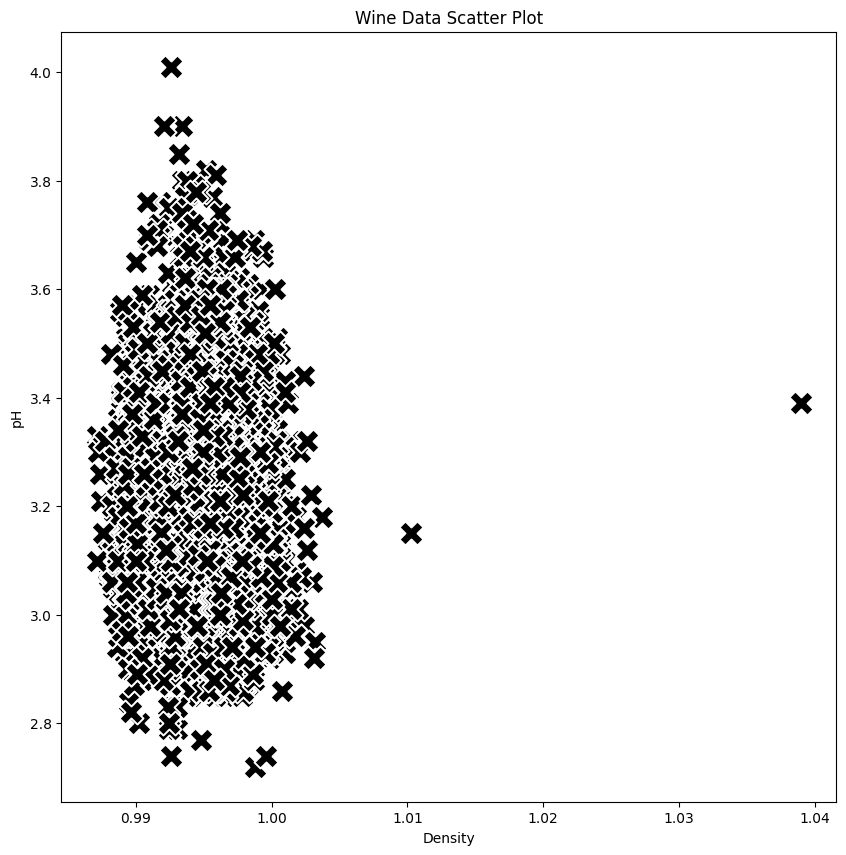

In [12]:
plt.figure(figsize=(10,10))
sns.scatterplot(
    x=df['density'],
    y=df['pH'],
    color='black',
    s=300,
    marker='X'
)
plt.xlabel('Density')
plt.ylabel('pH')
plt.title('Wine Data Scatter Plot')
plt.show()

In [13]:
kmeansmodel = KMeans(n_clusters=2, random_state=42)
clusters = kmeansmodel.fit_predict(X_sclaing)
df['Clusters'] = clusters
print(df.head())

    type  fixed acidity  volatile acidity  citric acid  residual sugar  \
0  white            7.0              0.27         0.36            20.7   
1  white            6.3              0.30         0.34             1.6   
2  white            8.1              0.28         0.40             6.9   
3  white            7.2              0.23         0.32             8.5   
4  white            7.2              0.23         0.32             8.5   

   chlorides  free sulfur dioxide  total sulfur dioxide  density    pH  \
0      0.045                 45.0                 170.0   1.0010  3.00   
1      0.049                 14.0                 132.0   0.9940  3.30   
2      0.050                 30.0                  97.0   0.9951  3.26   
3      0.058                 47.0                 186.0   0.9956  3.19   
4      0.058                 47.0                 186.0   0.9956  3.19   

   sulphates  alcohol  quality  Clusters  
0       0.45      8.8        6         0  
1       0.49      9.5   

In [33]:
unseendataP = pd.DataFrame({
    'density': [2, 3, 5],
    'pH': [1, 2, 4]
})
print(unseendataP)

   density  pH
0        2   1
1        3   2
2        5   4


In [34]:
unseendataP_scaled = scaling.transform(unseendataP)
print(unseendataP_scaled)


[[ 335.27521693  -13.79880718]
 [ 668.78172673   -7.57892802]
 [1335.79474631    4.8608303 ]]


In [17]:
new_clusters = kmeansmodel.predict(unseendataP_scaled)
unseendataP['Cluster'] = new_clusters
print(unseendataP)


   density  pH  Cluster
0        2   1        0
1        3   2        0
2        5   4        0


In [19]:
unseendataP_scaled = scaling.transform(unseendataP[['density', 'pH']])
predict_new_cluster = kmeansmodel.predict(unseendataP_scaled)
print(predict_new_cluster)


[0 0 0]


<Axes: xlabel='density', ylabel='pH'>

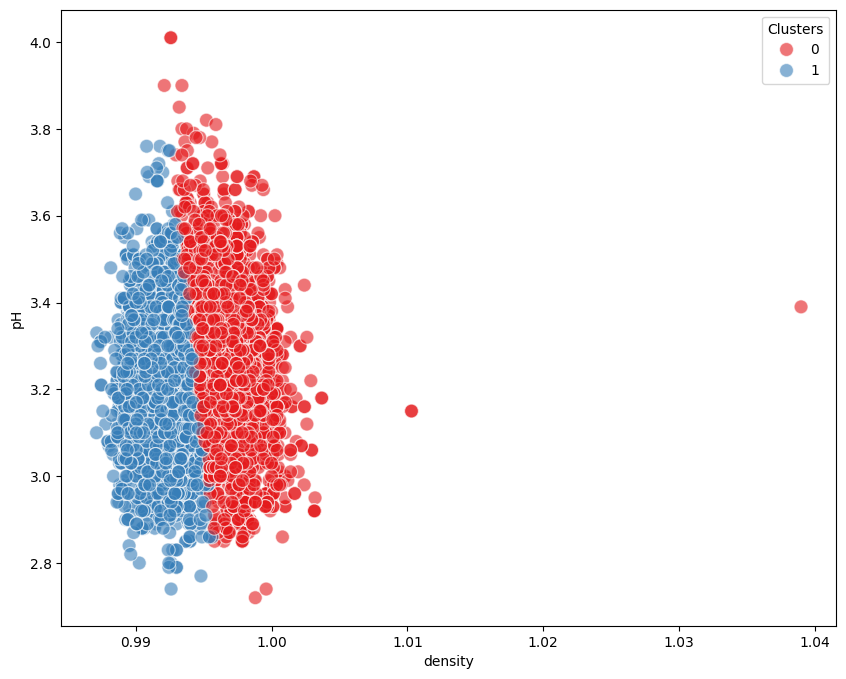

In [23]:
plt.figure(figsize=(10,8))
sns.scatterplot(
    x=df['density'],
    y=df['pH'],
    hue=df['Clusters'],
    palette='Set1',
    s=100,
    alpha=0.6
)

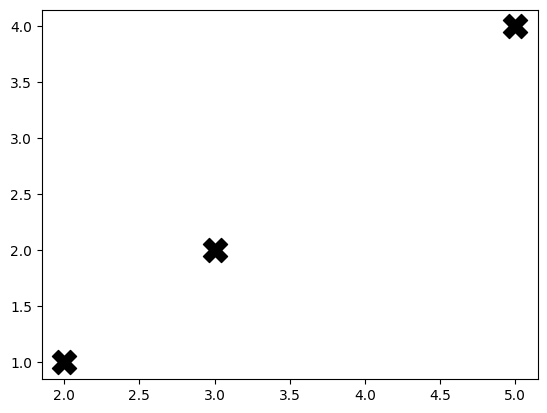

In [24]:
plt.scatter(
    x=unseendataP['density'],
    y=unseendataP['pH'],
    color='black',
    s=300,
    marker='X',
    label='New Data'
)

/tmp/ipython-input-2001470352.py:4: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


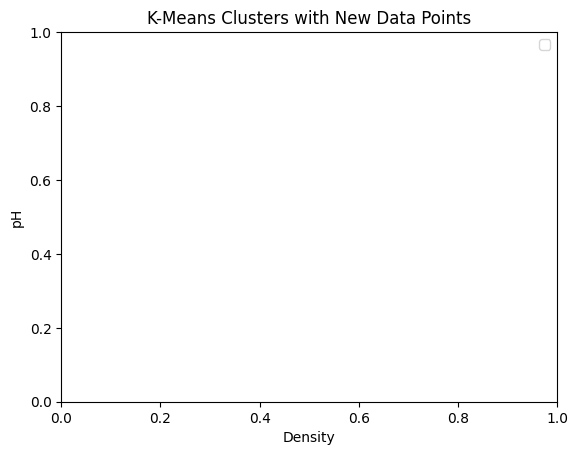

In [25]:
plt.xlabel('Density')
plt.ylabel('pH')
plt.title('K-Means Clusters with New Data Points')
plt.legend()
plt.show()

In [26]:
linked = linkage(X_sclaing, method='ward')

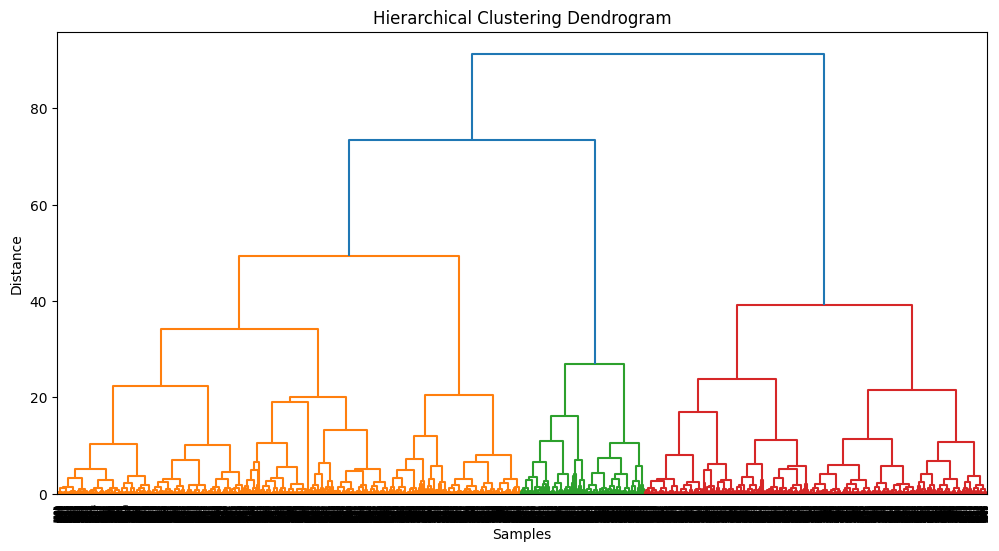

In [27]:
plt.figure(figsize=(12,6))
dendrogram(
    linked,
    orientation='top',
    distance_sort='descending',
    show_leaf_counts=False
)
plt.title('Hierarchical Clustering Dendrogram')
plt.xlabel('Samples')
plt.ylabel('Distance')
plt.show()


In [28]:
hier_clusters = fcluster(linked, t=2, criterion='maxclust')
df['Hier_Cluster'] = hier_clusters
df.head()


,type,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Clusters,Hier_Cluster
0,white,7.0,0.27,0.36,20.7,0.045,45.0,170.0,1.0010,3.00,0.45,8.8,6,0,2
1,white,6.3,0.30,0.34,1.6,0.049,14.0,132.0,0.9940,3.30,0.49,9.5,6,1,2
2,white,8.1,0.28,0.40,6.9,0.050,30.0,97.0,0.9951,3.26,0.44,10.1,6,0,2
3,white,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6,0,2
4,white,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6,0,2


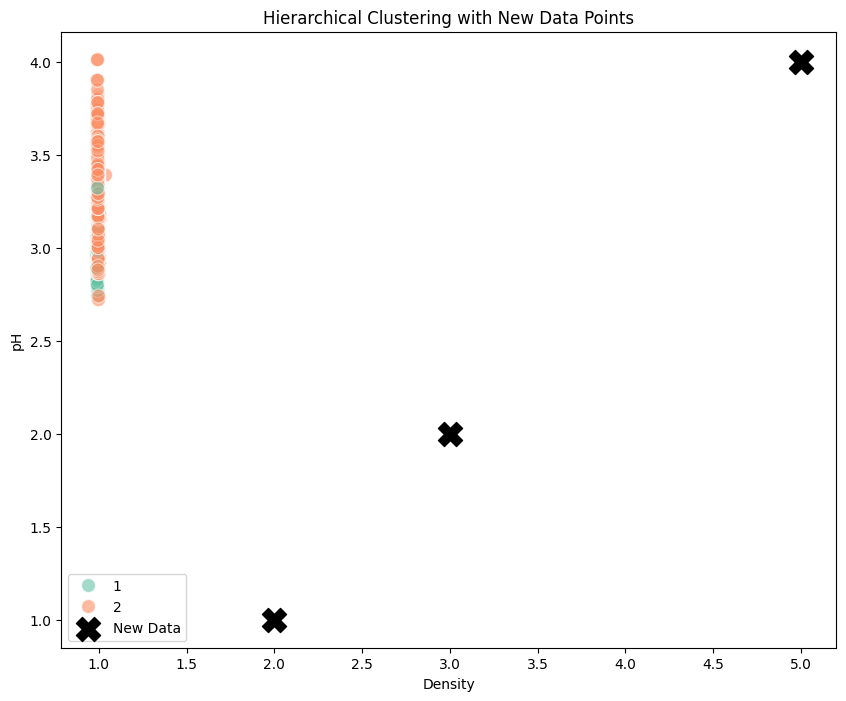

In [29]:
plt.figure(figsize=(10,8))

sns.scatterplot(
    x=df['density'],
    y=df['pH'],
    hue=df['Hier_Cluster'],
    palette='Set2',
    s=100,
    alpha=0.6
)

plt.scatter(
    x=unseendataP['density'],
    y=unseendataP['pH'],
    color='black',
    s=300,
    marker='X',
    label='New Data'
)

plt.xlabel('Density')
plt.ylabel('pH')
plt.title('Hierarchical Clustering with New Data Points')
plt.legend()
plt.show()


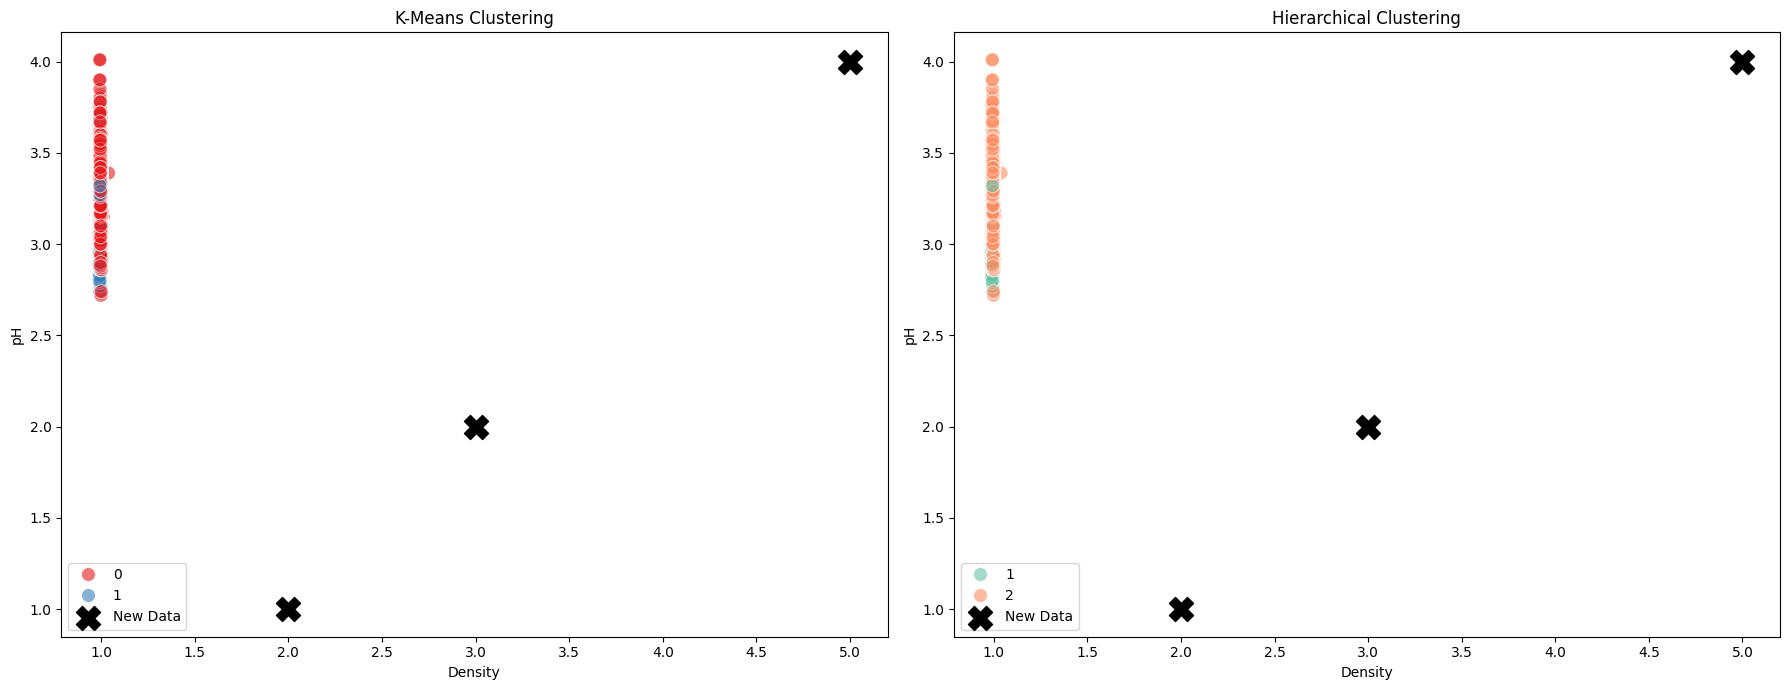

In [31]:
plt.figure(figsize=(18,7))

plt.subplot(1, 2, 1)
sns.scatterplot(
    x=df['density'],
    y=df['pH'],
    hue=df['Clusters'],
    palette='Set1',
    s=100,
    alpha=0.6
)
plt.scatter(
    x=unseendataP['density'],
    y=unseendataP['pH'],
    color='black',
    s=300,
    marker='X',
    label='New Data'
)
plt.xlabel('Density')
plt.ylabel('pH')
plt.title('K-Means Clustering')
plt.legend()

plt.subplot(1, 2, 2)
sns.scatterplot(
    x=df['density'],
    y=df['pH'],
    hue=df['Hier_Cluster'],
    palette='Set2',
    s=100,
    alpha=0.6
)
plt.scatter(
    x=unseendataP['density'],
    y=unseendataP['pH'],
    color='black',
    s=300,
    marker='X',
    label='New Data'
)
plt.xlabel('Density')
plt.ylabel('pH')
plt.title('Hierarchical Clustering')
plt.legend()

plt.tight_layout()
plt.show()


Summary of Findings

The objective of this analysis was to group wines based on their physical and chemical properties, specifically density (used as “Weight index”) and **pH”, using unsupervised learning techniques, namely K-Means and Hierarchical Clustering. The dataset, wine-quality-white-and-red.csv, contains various features, but for clustering, only density and pH were selected. Preprocessing involved encoding the categorical type column (white=1, red=0) and scaling the selected numeric features using StandardScaler to standardize their values.

For K-Means clustering, the model was configured with 2 clusters based on the elbow method and domain knowledge. The model was fitted on the scaled features, and cluster labels were assigned to each wine sample. Visualization using a scatter plot showed the clusters clearly, with new/unseen data points marked as black “X”, illustrating how they fit into the existing clusters. K-Means produced compact, well-separated clusters, making it straightforward to assign new data points.

Hierarchical clustering was performed using the Ward linkage method, and a dendrogram was plotted to visualize the hierarchical relationships between the samples. Clusters were assigned using a threshold to create two clusters. Visualization of hierarchical clusters showed slightly different groupings compared to K-Means, but both methods revealed meaningful patterns in the data. The new/unseen wines were also plotted on top of the hierarchical clusters, showing where they fell relative to existing samples.

Comparing the two methods, K-Means generated spherical clusters that are sensitive to scaling and easy to use for predicting new points, while hierarchical clustering provided insight into the nested relationships between samples. Overall, both methods effectively separated wines based on density and pH, and the analysis demonstrated that new data could be reliably assigned to clusters using the trained K-Means model. This workflow can be extended by including additional features or experimenting with more clusters to gain deeper insights into wine characteristics.